kernal SVM

In [1]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data.csv")
data

,Income_Thousand,CIBIL_Score,Existing_Loan,Employment_Type,Age,Loan_Amount_Lakh,Loan_Status
0,71,757,Yes,Salaried,27,21,Approved
1,112,680,No,Business,28,17,Approved
2,34,701,No,Salaried,35,23,Approved
3,91,603,Yes,Business,49,5,Rejected
4,80,669,Yes,Salaried,53,22,Approved
...,...,...,...,...,...,...,...
295,51,619,Yes,Salaried,36,14,Rejected
296,28,801,Yes,Salaried,44,2,Approved
297,118,824,No,Business,39,4,Approved
298,38,731,No,Business,28,17,Approved


In [3]:
data["Existing_Loan"] = data["Existing_Loan"].map({"Yes":1,"No":0})
data["Employment_Type"] = data["Employment_Type"].map({"Salaried":1,"Business":0})
data["Loan_Status"] = data["Loan_Status"].map({"Approved":1,"Rejected":0})
data

,Income_Thousand,CIBIL_Score,Existing_Loan,Employment_Type,Age,Loan_Amount_Lakh,Loan_Status
0,71,757,1,1,27,21,1
1,112,680,0,0,28,17,1
2,34,701,0,1,35,23,1
3,91,603,1,0,49,5,0
4,80,669,1,1,53,22,1
...,...,...,...,...,...,...,...
295,51,619,1,1,36,14,0
296,28,801,1,1,44,2,1
297,118,824,0,0,39,4,1
298,38,731,0,0,28,17,1


In [4]:
X = data[["Income_Thousand","CIBIL_Score"]]
y = data["Loan_Status"]

In [5]:
"""X = data.drop("Loan_Status",axis=1)
y = data["Loan_Status"]"""

'X = data.drop("Loan_Status",axis=1)\ny = data["Loan_Status"]'

In [6]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
model = SVC(kernel='linear',random_state=42,C=100)

In [8]:
model.fit(x_train,y_train)

SVC(C=100, kernel='linear', random_state=42)

In [9]:
y_predict =model.predict(x_test)
print("accu",accuracy_score(y_test,y_predict))

accu 0.8166666666666667


In [10]:
"""new_cut = pd.DataFrame({
    'Income_Thousand': [70, 100, 30],
    'CIBIL_Score': [700, 780, 620],
    'Existing_Loan': [1, 0, 1],
    'Employment_Type': [1, 0, 1],
    'Age': [30, 45, 25],
    'Loan_Amount_Lakh': [15, 20, 10]
})"""

"new_cut = pd.DataFrame({\n    'Income_Thousand': [70, 100, 30],\n    'CIBIL_Score': [700, 780, 620],\n    'Existing_Loan': [1, 0, 1],\n    'Employment_Type': [1, 0, 1],\n    'Age': [30, 45, 25],\n    'Loan_Amount_Lakh': [15, 20, 10]\n})"

In [11]:
new_cut = pd.DataFrame({
    'Income_Thousand': [70, 100, 30],
    'CIBIL_Score': [700, 780, 620],
})

In [12]:
model.predict(new_cut)

array([1, 1, 0])

Text(0, 0.5, 'CIBIL Score')

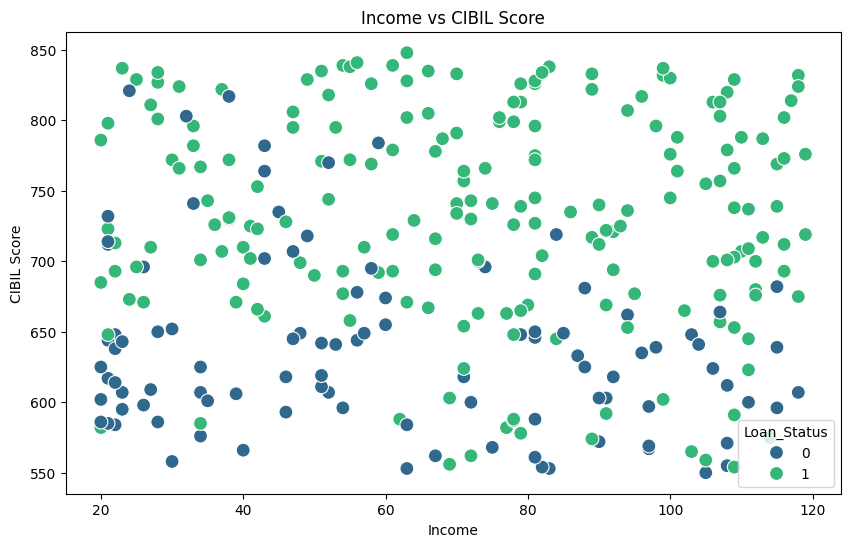

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = X.copy()
plot_data['Loan_Status'] = y

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='Income_Thousand', y='CIBIL_Score', hue='Loan_Status', palette='viridis', s=100)
plt.title('Income vs CIBIL Score')
plt.xlabel('Income')
plt.ylabel('CIBIL Score')
#plt.grid(True)
plt.show()

c:\Users\Rudraksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'approved vs not approved')

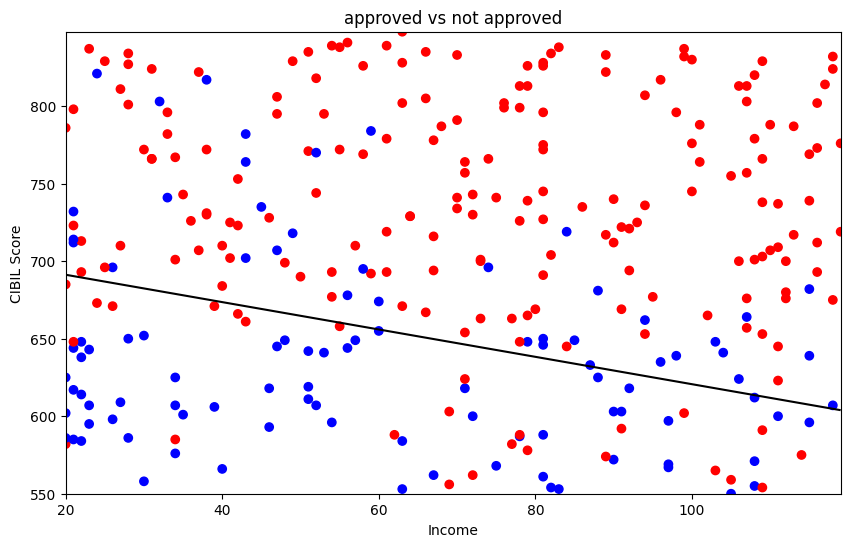

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), 200),
    np.linspace(X.iloc[:,1].min(), X.iloc[:,1].max(), 200)
)

# Get decision function values
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw decision boundary
plt.contour(xx, yy, Z, levels=[0], colors='black')


plt.scatter(X["Income_Thousand"], X["CIBIL_Score"], c=y, cmap='bwr')

plt.xlabel("Income")
plt.ylabel("CIBIL Score")
plt.title("approved vs not approved")